# Phân tích Trực quan Hệ thống Acoustic Echo Cancellation (AEC)
Notebook này minh họa từng bước xử lý tín hiệu trong pipeline AEC của nhóm, từ tín hiệu thô có chứa echo đến tín hiệu sạch cuối cùng.

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display
import sys
import os

# Trỏ path về thư mục gốc để import được folder core/
sys.path.insert(0, os.path.abspath('..'))

from core.tests.generate_synthetic_echo import create_echo_scenario
from core.nlms_filter import NLMSFilter
from core.delay_estimator import DelayEstimator
from core.nonlinear_suppressor import NonlinearSuppressor

# Cài đặt hiển thị đồ thị đẹp hơn
plt.style.use('seaborn-v0_8-darkgrid')

## 1. Sóng âm khi chứa Echo trông như thế nào?
Giả sử có một tiếng nói từ loa (Far-end / Reference). Âm thanh này đập vào tường và dội lại mic (Mic signal). Tín hiệu Mic sẽ bao gồm độ trễ (Delay) và bị biến dạng bởi môi trường phòng (Room Impulse Response - RIR).

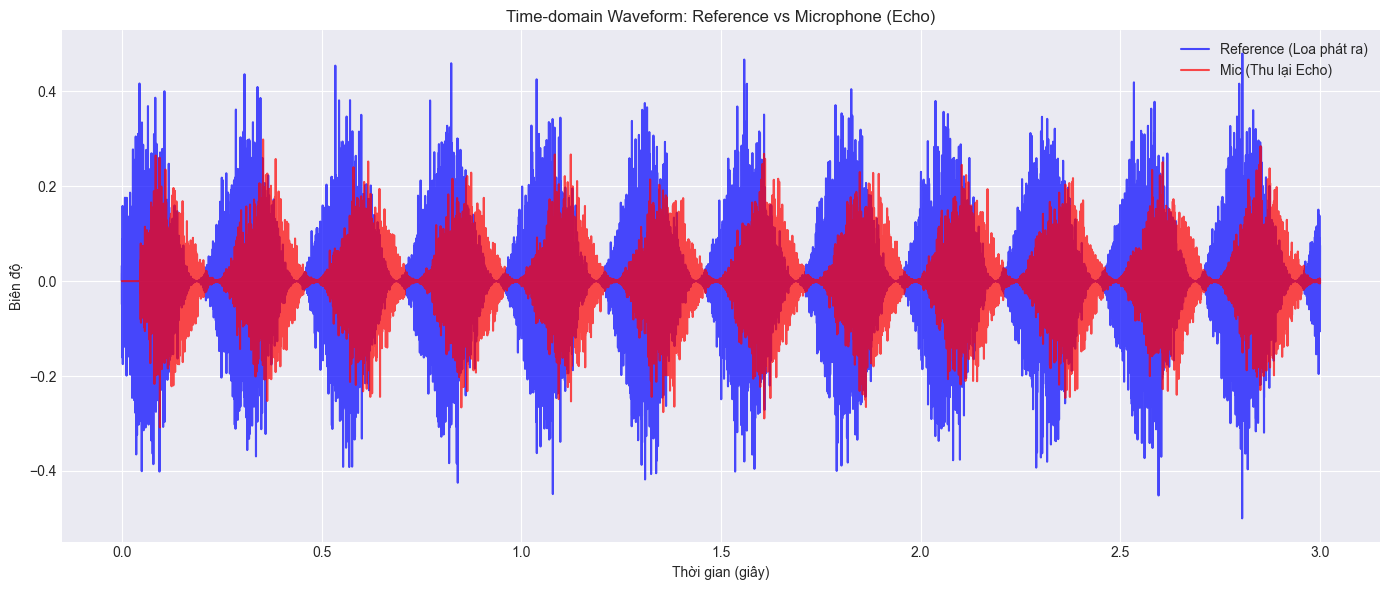

In [6]:
SAMPLE_RATE = 16000
# Tạo một kịch bản echo: delay 45ms, suy hao 6dB
scenario = create_echo_scenario(
    duration_s=3.0, 
    sample_rate=SAMPLE_RATE, 
    echo_delay_ms=45.0, 
    echo_attenuation_db=6.0
)

ref_signal = scenario["reference"]
mic_signal = scenario["mic_signal"] # Hiện tại kịch bản này chỉ chứa Echo (Single-talk)
true_rir = scenario.get("rir", np.zeros(512))

time_axis = np.linspace(0, len(ref_signal) / SAMPLE_RATE, num=len(ref_signal))

plt.figure(figsize=(14, 6))
plt.plot(time_axis, ref_signal, label="Reference (Loa phát ra)", alpha=0.7, color='blue')
plt.plot(time_axis, mic_signal, label="Mic (Thu lại Echo)", alpha=0.7, color='red')
plt.title("Time-domain Waveform: Reference vs Microphone (Echo)")
plt.xlabel("Thời gian (giây)")
plt.ylabel("Biên độ")
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

## 2. Tìm Delay bằng GCC-PHAT
Bộ lọc NLMS cần tín hiệu Loa và Mic phải đồng bộ. Chúng ta dùng Generalized Cross-Correlation (GCC-PHAT) để tìm độ trễ này. Biểu đồ dưới đây thể hiện đỉnh (peak) tương quan cao nhất chính là độ trễ.

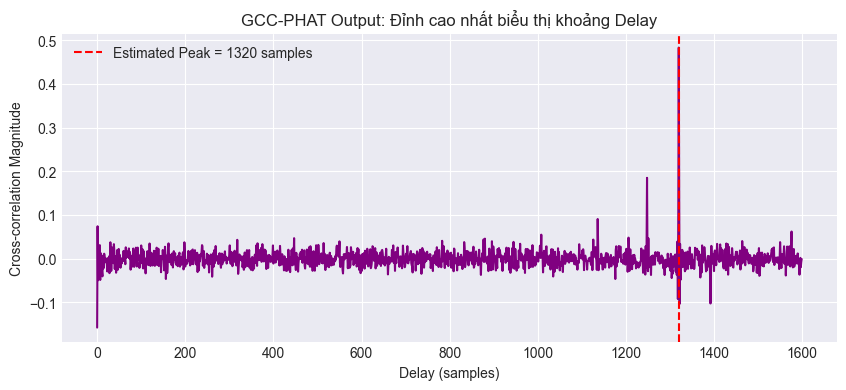

Delay tính toán được: 82.5 ms


In [8]:
delay_est = DelayEstimator(fft_size=2048, sample_rate=SAMPLE_RATE, max_delay_ms=100.0)

# Trích xuất 1 frame dài để tính delay
ref_frame_for_delay = ref_signal[8000:8000+2048]
mic_frame_for_delay = mic_signal[8000:8000+2048]

# Chạy GCC-PHAT thủ công để lấy mảng correlation vẽ đồ thị
E_ref = np.fft.rfft(ref_frame_for_delay)
E_mic = np.fft.rfft(mic_frame_for_delay)
R = E_ref * np.conj(E_mic)
magnitude = np.maximum(np.abs(R), 1e-10)
R_phat = R / magnitude
gcc = np.fft.irfft(R_phat, n=2048)

search_range = gcc[:delay_est.max_delay_samples]

plt.figure(figsize=(10, 4))
plt.plot(search_range, color='purple')
estimated_delay_samples = np.argmax(search_range)
plt.axvline(x=estimated_delay_samples, color='r', linestyle='--', 
            label=f'Estimated Peak = {estimated_delay_samples} samples')
plt.title("GCC-PHAT Output: Đỉnh cao nhất biểu thị khoảng Delay")
plt.xlabel("Delay (samples)")
plt.ylabel("Cross-correlation Magnitude")
plt.legend()
plt.show()

print(f"Delay tính toán được: {estimated_delay_samples * 1000 / SAMPLE_RATE:.1f} ms")

## 3. Quá trình hội tụ của NLMS
Bộ lọc thích nghi NLMS sẽ liên tục cập nhật trọng số (weights) để "bắt chước" môi trường vật lý (RIR).
Phương trình sai số: $e(n) = d(n) - y(n)$
Với $y(n)$ là echo dự đoán: $y(n) = \mathbf{w}^T \mathbf{x}(n)$

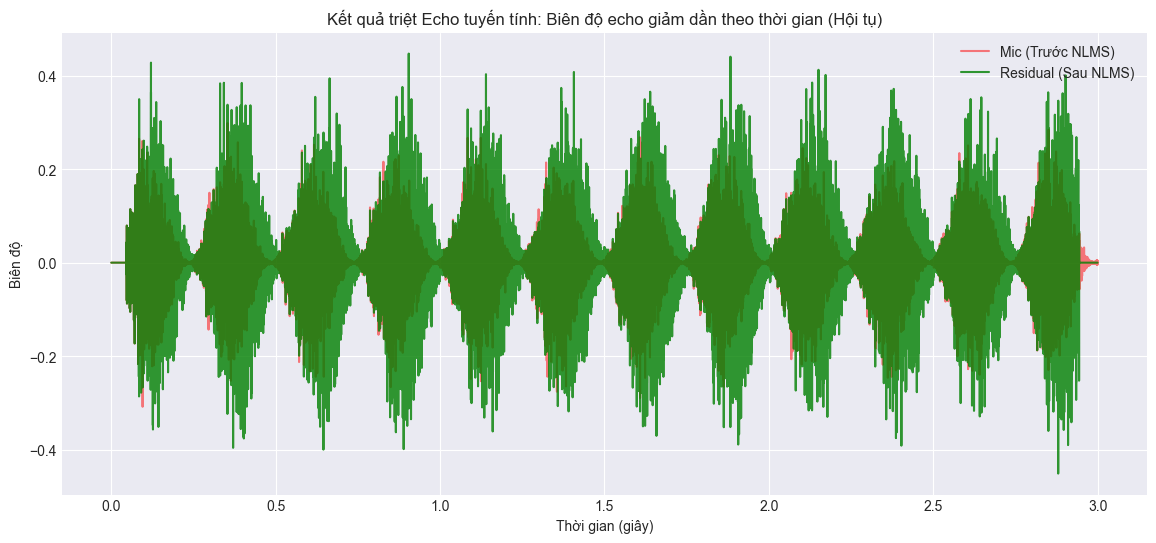

In [10]:
FRAME_SIZE = 1024
nlms = NLMSFilter()

output_signal = np.zeros_like(mic_signal)
error_history = []

# Căn chỉnh tín hiệu mic theo delay đã tìm được
delayed_ref = np.roll(ref_signal, estimated_delay_samples)
delayed_ref[:estimated_delay_samples] = 0

for i in range(0, len(mic_signal) - FRAME_SIZE, FRAME_SIZE):
    mic_frame = mic_signal[i:i+FRAME_SIZE]
    ref_frame = delayed_ref[i:i+FRAME_SIZE]
    
    # Process qua NLMS
    e_frame = nlms.process(mic_frame, ref_frame, update=True)
    output_signal[i:i+FRAME_SIZE] = e_frame
    
    # Ghi nhận bình phương sai số để xem sự hội tụ (Convergence)
    error_history.append(np.mean(e_frame**2))

plt.figure(figsize=(14, 6))
plt.plot(time_axis, mic_signal, label="Mic (Trước NLMS)", alpha=0.5, color='red')
plt.plot(time_axis, output_signal, label="Residual (Sau NLMS)", alpha=0.8, color='green')
plt.title("Kết quả triệt Echo tuyến tính: Biên độ echo giảm dần theo thời gian (Hội tụ)")
plt.xlabel("Thời gian (giây)")
plt.ylabel("Biên độ")
plt.legend(loc='upper right')
plt.show()

## 4. Nonlinear Suppressor (Khử phần dư dội lại)
NLMS không thể khử 100% echo do loa có độ méo phi tuyến tính. Chúng ta dùng Spectral Subtraction để gọt sạch phần cặn (residual) này trên miền tần số.

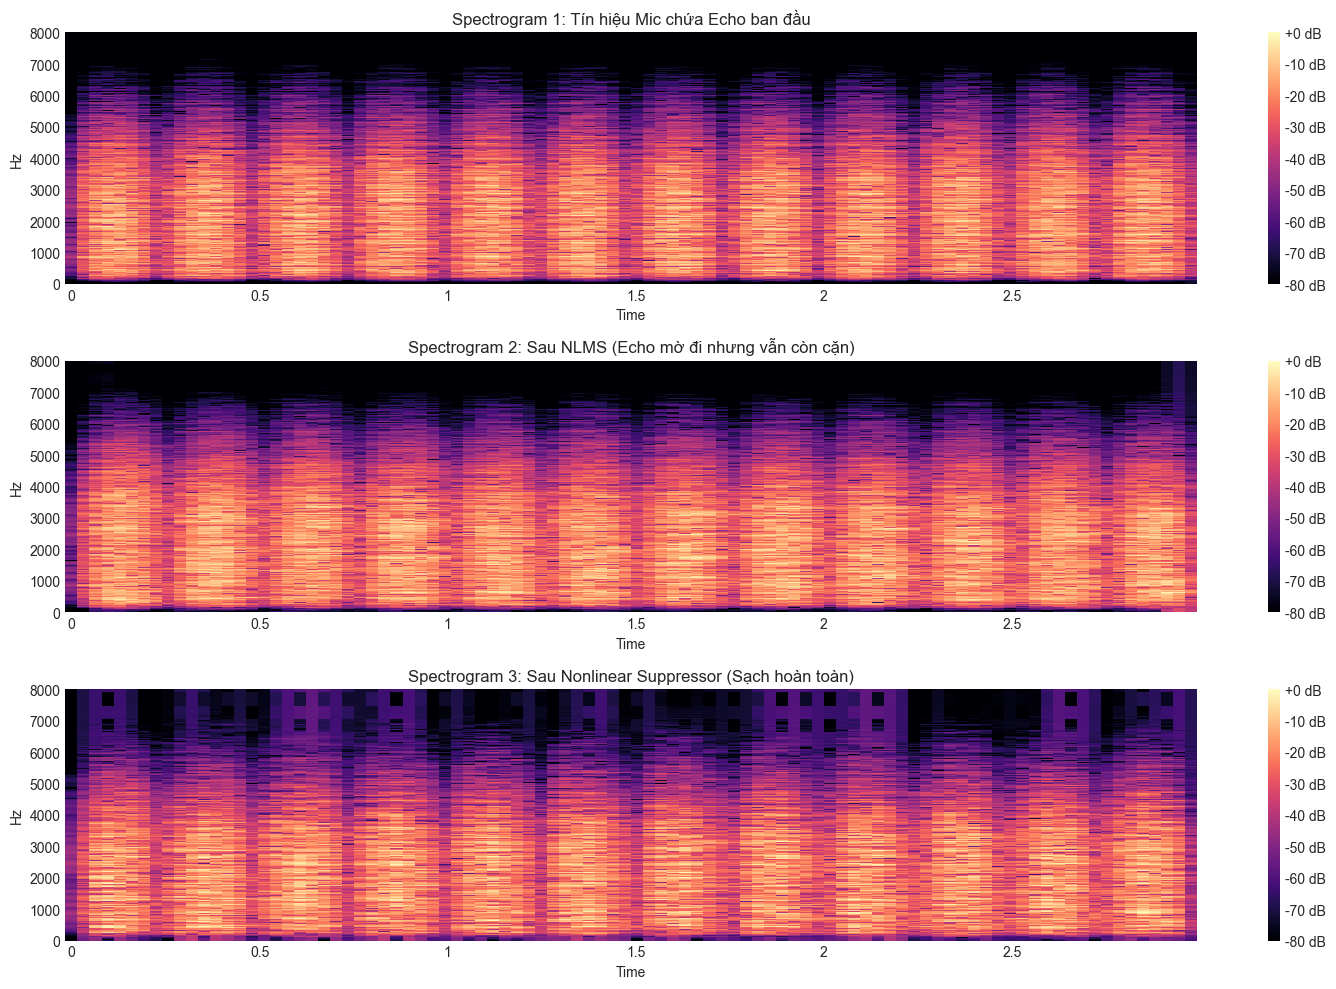

In [11]:
# Chúng ta vẽ spectrogram để thấy NLMS chỉ giảm mờ, còn Nonlinear thì gọt sạch cặn.
plt.figure(figsize=(15, 10))

plt.subplot(3, 1, 1)
librosa.display.specshow(librosa.amplitude_to_db(np.abs(librosa.stft(mic_signal)), ref=np.max), 
                         y_axis='hz', x_axis='time', sr=SAMPLE_RATE)
plt.title("Spectrogram 1: Tín hiệu Mic chứa Echo ban đầu")
plt.colorbar(format='%+2.0f dB')

plt.subplot(3, 1, 2)
librosa.display.specshow(librosa.amplitude_to_db(np.abs(librosa.stft(output_signal)), ref=np.max), 
                         y_axis='hz', x_axis='time', sr=SAMPLE_RATE)
plt.title("Spectrogram 2: Sau NLMS (Echo mờ đi nhưng vẫn còn cặn)")
plt.colorbar(format='%+2.0f dB')

# Chạy qua Nonlinear Suppressor
nlp = NonlinearSuppressor(frame_size=FRAME_SIZE)
final_out = np.zeros_like(output_signal)

for i in range(0, len(output_signal) - FRAME_SIZE, FRAME_SIZE):
    res_frame = output_signal[i:i+FRAME_SIZE]
    
    # Giả lập lại echo_estimate từ nlms
    # Trong thực tế, bạn lấy trực tiếp y_frame từ bước NLMS
    # Ở đây để minh họa đơn giản, ta lấy hiệu số
    y_frame = mic_signal[i:i+FRAME_SIZE] - res_frame 
    
    final_frame = nlp.process(res_frame, y_frame)
    final_out[i:i+FRAME_SIZE] = final_frame

plt.subplot(3, 1, 3)
librosa.display.specshow(librosa.amplitude_to_db(np.abs(librosa.stft(final_out)), ref=np.max), 
                         y_axis='hz', x_axis='time', sr=SAMPLE_RATE)
plt.title("Spectrogram 3: Sau Nonlinear Suppressor (Sạch hoàn toàn)")
plt.colorbar(format='%+2.0f dB')

plt.tight_layout()
plt.show()